In [1]:
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pandas as pd

In [2]:
df = pd.read_csv('bbc_news_dataset.csv')
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ArticleId  1490 non-null   int64
 1   Text       1490 non-null   str  
 2   Category   1490 non-null   str  
dtypes: int64(1), str(2)
memory usage: 35.1 KB
None


In [11]:
X = df['Text']
Y = df['Category']

In [3]:
valueCounts = df['Category'].value_counts()
print(valueCounts)

Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64


In [4]:
categoryNames = df['Category'].unique()
print(categoryNames)

<StringArray>
['business', 'tech', 'politics', 'sport', 'entertainment']
Length: 5, dtype: str


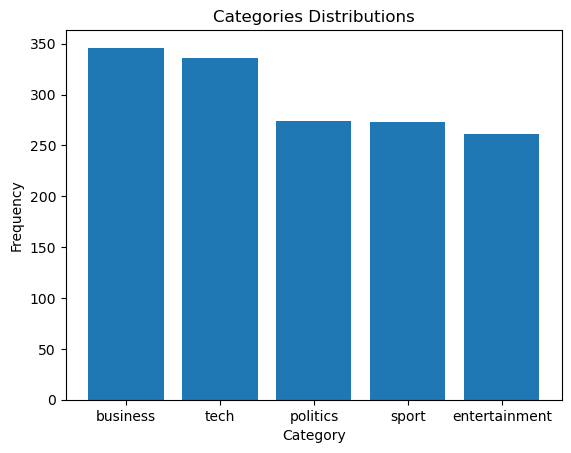

In [5]:
plt.bar(x = categoryNames, height = valueCounts)
plt.title('Categories Distributions')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.show()

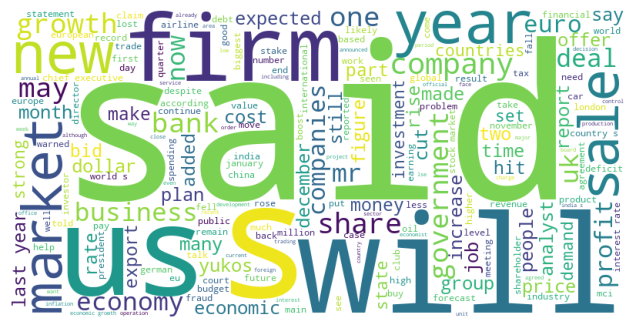

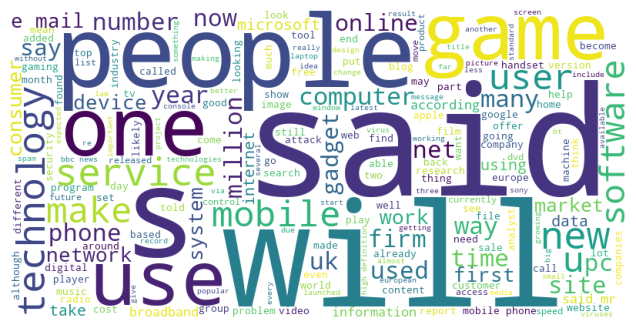

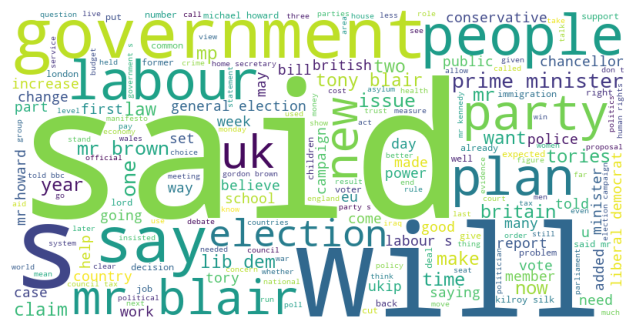

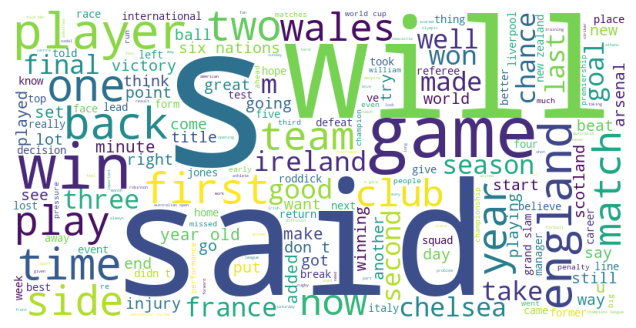

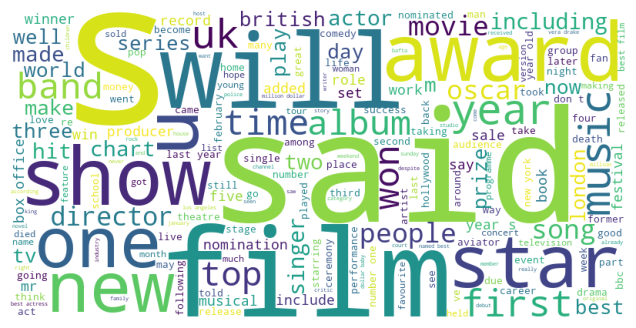

In [25]:
for category in categoryNames:
    text = " ".join(df[df['Category']==category]['Text'].values)
    wc = WordCloud(width=800,height=400,
    background_color='white').generate(text)
    plt.figure(figsize=(8,4))
    plt.imshow(wc)
    plt.axis('off')
    plt.show()

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
print(f"Training set size: {X_train}")
# print(f"Test set size: {X_test}")
# print(f"Training labels size: {y_train}")
# print(f"Test labels size: {y_test}")

In [16]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
model = make_pipeline(
    TfidfVectorizer(stop_words='english'),
    MultinomialNB()
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

     business       0.94      0.97      0.95        75
entertainment       1.00      0.96      0.98        46
     politics       0.91      0.95      0.93        56
        sport       0.97      1.00      0.98        63
         tech       0.98      0.90      0.94        58

     accuracy                           0.96       298
    macro avg       0.96      0.95      0.96       298
 weighted avg       0.96      0.96      0.96       298



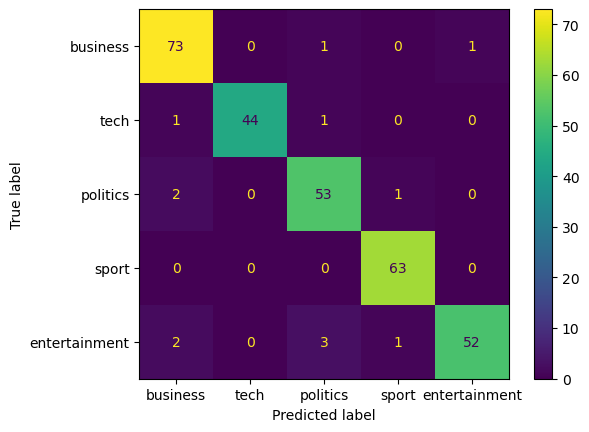

In [19]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm,
display_labels=categoryNames).plot()

In [20]:
texts = ['Enter any news article text here.']
prediction = model.predict(texts)
print(prediction)

['tech']


In [21]:
import joblib
joblib.dump(model,'model.joblib')
print('SUCCESS')

SUCCESS
